In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
    # for filename in filenames:
        # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# AI-Powered Product Intelligence System Using OpenAI CLIP

## Generative AI Bootcamp – Day 2 Assignment

**Name:** Kunal Kumar Kamat  
**Branch:** Computer Science and Engineering (CSE)  
**College:** Dayananda Sagar Academy of Technology and Management (DSATM)


## Project Overview

This notebook presents an AI-powered product intelligence system for an e-commerce platform using OpenAI's CLIP model. By learning a shared representation for images and text, CLIP enables the system to recommend visually similar products, identify duplicate listings, and retrieve products from natural language queries.

## Features Implemented

- Smart Product Recommendation Engine
- Unique Product Catalog Creation
- Reverse Product Search (Text-to-Image)

## Objective

The objective of this project is to demonstrate how multimodal AI can improve product discovery and catalog management in e-commerce through image similarity search, duplicate detection, and text-based product retrieval.

## Stage 0.1 – Environment Setup

This stage prepares the execution environment by installing the required libraries and dependencies needed to build the AI-powered product intelligence system.

In [2]:
!pip install git+https://github.com/openai/CLIP.git
!pip install ftfy regex tqdm scikit-learn

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-qhasr8dm
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-qhasr8dm
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369547 sha256=06c506fb8083f1c88b8f452b351d0e6578741ba37fd6353c1d701e58d5f495e0
  Stored in directory: /tmp/pip-ephem-wheel-cache-bnul3l01/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [3]:
import clip
print("CLIP installed successfully!")

CLIP installed successfully!


## Stage 0.2 – Import Libraries and Load the CLIP Model

This stage imports the required Python libraries for data processing, image handling, visualization, and similarity computation. It also initializes the OpenAI CLIP model, which is used to generate image and text embeddings for the subsequent tasks.

In [4]:
import os
import glob
import json

import numpy as np
import pandas as pd

import torch
import clip

from PIL import Image
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

# Detect GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load CLIP model
model, preprocess = clip.load("ViT-B/32", device=device)

print("CLIP loaded successfully!")
print("Running on:", device)

100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 92.7MiB/s]


CLIP loaded successfully!
Running on: cuda


In [5]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/paramaggarwal
/kaggle/input/datasets/paramaggarwal/fashion-product-images-small
/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset
/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/images
/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images


In [6]:
import glob

path1 = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images"
path2 = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/images"

print("Path 1:", len(glob.glob(path1 + "/*.jpg")))
print("Path 2:", len(glob.glob(path2 + "/*.jpg")))

Path 1: 44441
Path 2: 44441


## Stage 0.3 – Load the Product Dataset

This stage loads the fashion product dataset and organizes the product information into a structured DataFrame. The dataset includes product image paths and corresponding product IDs, which serve as the input for feature extraction and the subsequent product intelligence tasks.

In [7]:
import os
import glob
import pandas as pd

# Correct image directory
image_dir = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images"

# Get all image paths
image_paths = glob.glob(os.path.join(image_dir, "*.jpg"))

print("Total images found:", len(image_paths))

# Use first 2000 images for faster execution
image_paths = image_paths[:2000]

# Create DataFrame
df = pd.DataFrame({
    "image_path": image_paths
})

# Extract Product ID
df["product_id"] = df["image_path"].apply(
    lambda p: os.path.basename(p).split(".")[0]
)

print(df.head())

Total images found: 44441
                                          image_path product_id
0  /kaggle/input/datasets/paramaggarwal/fashion-p...      31973
1  /kaggle/input/datasets/paramaggarwal/fashion-p...      30778
2  /kaggle/input/datasets/paramaggarwal/fashion-p...      19812
3  /kaggle/input/datasets/paramaggarwal/fashion-p...      22735
4  /kaggle/input/datasets/paramaggarwal/fashion-p...      38246


## Stage 0.4 – Generate CLIP Image Embeddings

This stage generates CLIP image embeddings for all products in the dataset. The extracted embeddings capture the semantic features of each product image and are reused throughout the notebook for product recommendation, duplicate product detection, and reverse product search.

In [8]:
def get_image_embedding(path):

    image = preprocess(
        Image.open(path).convert("RGB")
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model.encode_image(image)
        embedding /= embedding.norm(dim=-1, keepdim=True)

    return embedding.cpu().numpy().flatten()

In [9]:
# Test on one image

sample_embedding = get_image_embedding(df["image_path"].iloc[0])

print(sample_embedding.shape)

(512,)


In [10]:
embeddings = []

for path in df["image_path"]:
    embeddings.append(get_image_embedding(path))

image_embeddings = np.vstack(embeddings)

np.save("image_embeddings.npy", image_embeddings)

print(image_embeddings.shape)

(2000, 512)


## Stage 1 – Smart Product Recommendation Engine

### Objective

Develop an AI-powered recommendation engine that identifies visually similar fashion products using CLIP image embeddings.

### Workflow

1. Select a query product from the dataset.
2. Generate or retrieve its CLIP image embedding.
3. Compare the query embedding with all product embeddings using cosine similarity.
4. Retrieve the Top-5 most visually similar products.
5. Display the recommended products for comparison.

In [11]:
# Function to recommend similar products

def recommend_products(product_index, top_k=5):
    
    # Get similarity scores
    similarities = cosine_similarity(
        [image_embeddings[product_index]],
        image_embeddings
    )[0]

    # Sort in descending order
    indices = similarities.argsort()[::-1]

    # Remove the query image itself
    indices = indices[indices != product_index]

    # Return top recommendations
    return indices[:top_k]

In [12]:
# STEP 1: LOAD PRODUCT METADATA

import pandas as pd

# Load the metadata file
styles_df = pd.read_csv(
    "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv",
    on_bad_lines="skip"
)

# Select only the required columns
styles_df = styles_df[
    ["id", "masterCategory", "subCategory", "articleType"]
]

# Convert product IDs to string for merging
styles_df["id"] = styles_df["id"].astype(str)

# Display first few rows
styles_df.head()

,id,masterCategory,subCategory,articleType
0,15970,Apparel,Topwear,Shirts
1,39386,Apparel,Bottomwear,Jeans
2,59263,Accessories,Watches,Watches
3,21379,Apparel,Bottomwear,Track Pants
4,53759,Apparel,Topwear,Tshirts


In [13]:
# Step 2: Merge Product Metadata with Existing Dataset

# Convert product IDs to string
df["product_id"] = df["product_id"].astype(str)

# Remove old metadata columns (prevents _x and _y columns if this cell is run again)
df = df.drop(
    columns=["id", "masterCategory", "subCategory", "articleType"],
    errors="ignore"
)

# Merge metadata into the main dataframe
df = df.merge(
    styles_df,
    left_on="product_id",
    right_on="id",
    how="left"
)

# Display the merged dataframe
df.head()

,image_path,product_id,id,masterCategory,subCategory,articleType
0,/kaggle/input/datasets/paramaggarwal/fashion-p...,31973,31973,Footwear,Shoes,Sports Shoes
1,/kaggle/input/datasets/paramaggarwal/fashion-p...,30778,30778,Apparel,Topwear,Kurtas
2,/kaggle/input/datasets/paramaggarwal/fashion-p...,19812,19812,Apparel,Topwear,Sweatshirts
3,/kaggle/input/datasets/paramaggarwal/fashion-p...,22735,22735,Footwear,Shoes,Sports Shoes
4,/kaggle/input/datasets/paramaggarwal/fashion-p...,38246,38246,Apparel,Topwear,Tshirts


In [14]:
# VERIFY THE MERGED DATA

print("Total Products :", len(df))
print("\nColumns Available:\n")
print(df.columns)

print("\nSample Product\n")

print(df.loc[
    1000,
    [
        "product_id",
        "masterCategory",
        "subCategory",
        "articleType"
    ]
])

Total Products : 2000

Columns Available:

Index(['image_path', 'product_id', 'id', 'masterCategory', 'subCategory',
       'articleType'],
      dtype='object')

Sample Product

product_id             17291
masterCategory       Apparel
subCategory       Bottomwear
articleType         Trousers
Name: 1000, dtype: object


In [15]:
# STEP 3: EXPLORE AVAILABLE PRODUCT CATEGORIES

print("=" * 60)
print("AVAILABLE SUB CATEGORIES")
print("=" * 60)

subcategories = sorted(df["subCategory"].dropna().unique())

for i, category in enumerate(subcategories, start=1):
    print(f"{i:2d}. {category}")

print("\nTotal Sub Categories :", len(subcategories))

AVAILABLE SUB CATEGORIES
 1. Accessories
 2. Bags
 3. Bath and Body
 4. Belts
 5. Bottomwear
 6. Cufflinks
 7. Dress
 8. Eyes
 9. Eyewear
10. Flip Flops
11. Fragrance
12. Free Gifts
13. Hair
14. Headwear
15. Innerwear
16. Jewellery
17. Lips
18. Loungewear and Nightwear
19. Makeup
20. Nails
21. Sandal
22. Saree
23. Scarves
24. Shoes
25. Skin
26. Skin Care
27. Socks
28. Sports Equipment
29. Stoles
30. Ties
31. Topwear
32. Wallets
33. Watches

Total Sub Categories : 33


In [16]:
complementary_map = {

    # Clothing
    "Topwear": [
        "Bottomwear",
        "Shoes",
        "Watches",
        "Bags",
        "Belts"
    ],

    "Bottomwear": [
        "Topwear",
        "Shoes",
        "Belts",
        "Watches",
        "Bags"
    ],

    "Dress": [
        "Shoes",
        "Bags",
        "Jewellery",
        "Watches",
        "Scarves"
    ],

    "Saree": [
        "Jewellery",
        "Bags",
        "Sandal",
        "Watches",
        "Scarves"
    ],

    "Innerwear": [
        "Loungewear and Nightwear",
        "Bottomwear",
        "Topwear",
        "Socks",
        "Flip Flops"
    ],

    "Loungewear and Nightwear": [
        "Innerwear",
        "Flip Flops",
        "Socks",
        "Bath and Body",
        "Fragrance"
    ],

    # Footwear
    "Shoes": [
        "Socks",
        "Bottomwear",
        "Topwear",
        "Watches",
        "Bags"
    ],

    "Sandal": [
        "Dress",
        "Saree",
        "Bags",
        "Jewellery",
        "Watches"
    ],

    "Flip Flops": [
        "Loungewear and Nightwear",
        "Bath and Body",
        "Fragrance",
        "Socks",
        "Topwear"
    ],

    # Accessories
    "Bags": [
        "Wallets",
        "Topwear",
        "Shoes",
        "Watches",
        "Belts"
    ],

    "Belts": [
        "Bottomwear",
        "Topwear",
        "Shoes",
        "Wallets",
        "Watches"
    ],

    "Wallets": [
        "Belts",
        "Bags",
        "Shoes",
        "Watches",
        "Topwear"
    ],

    "Watches": [
        "Topwear",
        "Bottomwear",
        "Shoes",
        "Belts",
        "Eyewear"
    ],

    "Eyewear": [
        "Topwear",
        "Watches",
        "Bags",
        "Shoes",
        "Wallets"
    ],

    "Jewellery": [
        "Dress",
        "Saree",
        "Watches",
        "Bags",
        "Eyewear"
    ],

    "Scarves": [
        "Topwear",
        "Dress",
        "Bags",
        "Watches",
        "Jewellery"
    ],

    "Stoles": [
        "Dress",
        "Topwear",
        "Bags",
        "Jewellery",
        "Watches"
    ],

    "Ties": [
        "Topwear",
        "Bottomwear",
        "Belts",
        "Shoes",
        "Watches"
    ],

    "Socks": [
        "Shoes",
        "Bottomwear",
        "Topwear",
        "Flip Flops",
        "Loungewear and Nightwear"
    ],

    # Personal Care
    "Fragrance": [
        "Bath and Body",
        "Skin Care",
        "Hair",
        "Topwear",
        "Watches"
    ],

    "Bath and Body": [
        "Fragrance",
        "Skin Care",
        "Hair",
        "Flip Flops",
        "Loungewear and Nightwear"
    ],

    "Skin Care": [
        "Fragrance",
        "Bath and Body",
        "Hair",
        "Makeup",
        "Eyes"
    ],

    "Makeup": [
        "Eyes",
        "Lips",
        "Nails",
        "Skin Care",
        "Fragrance"
    ]
}

print("Complementary product rules created successfully!")

Complementary product rules created successfully!


In [17]:
# STEP 4: SMART RECOMMENDATION ALGORITHM

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_complementary_smart(product_id, top_k=5):
    """
    Smart Product Recommendation Engine

    Parameters
    ----------
    product_id : str
        ID of the input product

    top_k : int
        Maximum number of recommendations

    Returns
    -------
    pandas.DataFrame
        Recommended complementary products
    """

    # Step 4.1: Find the input product
    input_idx = df[df["product_id"] == str(product_id)].index[0]
    input_product = df.loc[input_idx]

    # Step 4.2: Get complementary categories
    complementary_categories = complementary_map.get(
        input_product["subCategory"],
        []
    )

    recommendations = []

    # Step 4.3: Find the best product from each complementary category
    for category in complementary_categories:

        candidates = df[df["subCategory"] == category]

        if candidates.empty:
            continue

        candidate_indices = candidates.index

        similarities = cosine_similarity(
            [image_embeddings[input_idx]],
            image_embeddings[candidate_indices]
        )[0]

        best_idx = candidate_indices[np.argmax(similarities)]

        recommendations.append(best_idx)

    # Step 4.4: Fill remaining recommendation slots
    if len(recommendations) < top_k:

        remaining = df[
            df["subCategory"].isin(complementary_categories)
        ].drop(index=recommendations, errors="ignore")

        if not remaining.empty:

            remaining_indices = remaining.index

            similarities = cosine_similarity(
                [image_embeddings[input_idx]],
                image_embeddings[remaining_indices]
            )[0]

            sorted_indices = np.argsort(similarities)[::-1]

            for idx in sorted_indices:

                recommendations.append(remaining_indices[idx])

                if len(recommendations) == top_k:
                    break

    # Step 4.5: Return the recommendations
    return df.loc[recommendations]

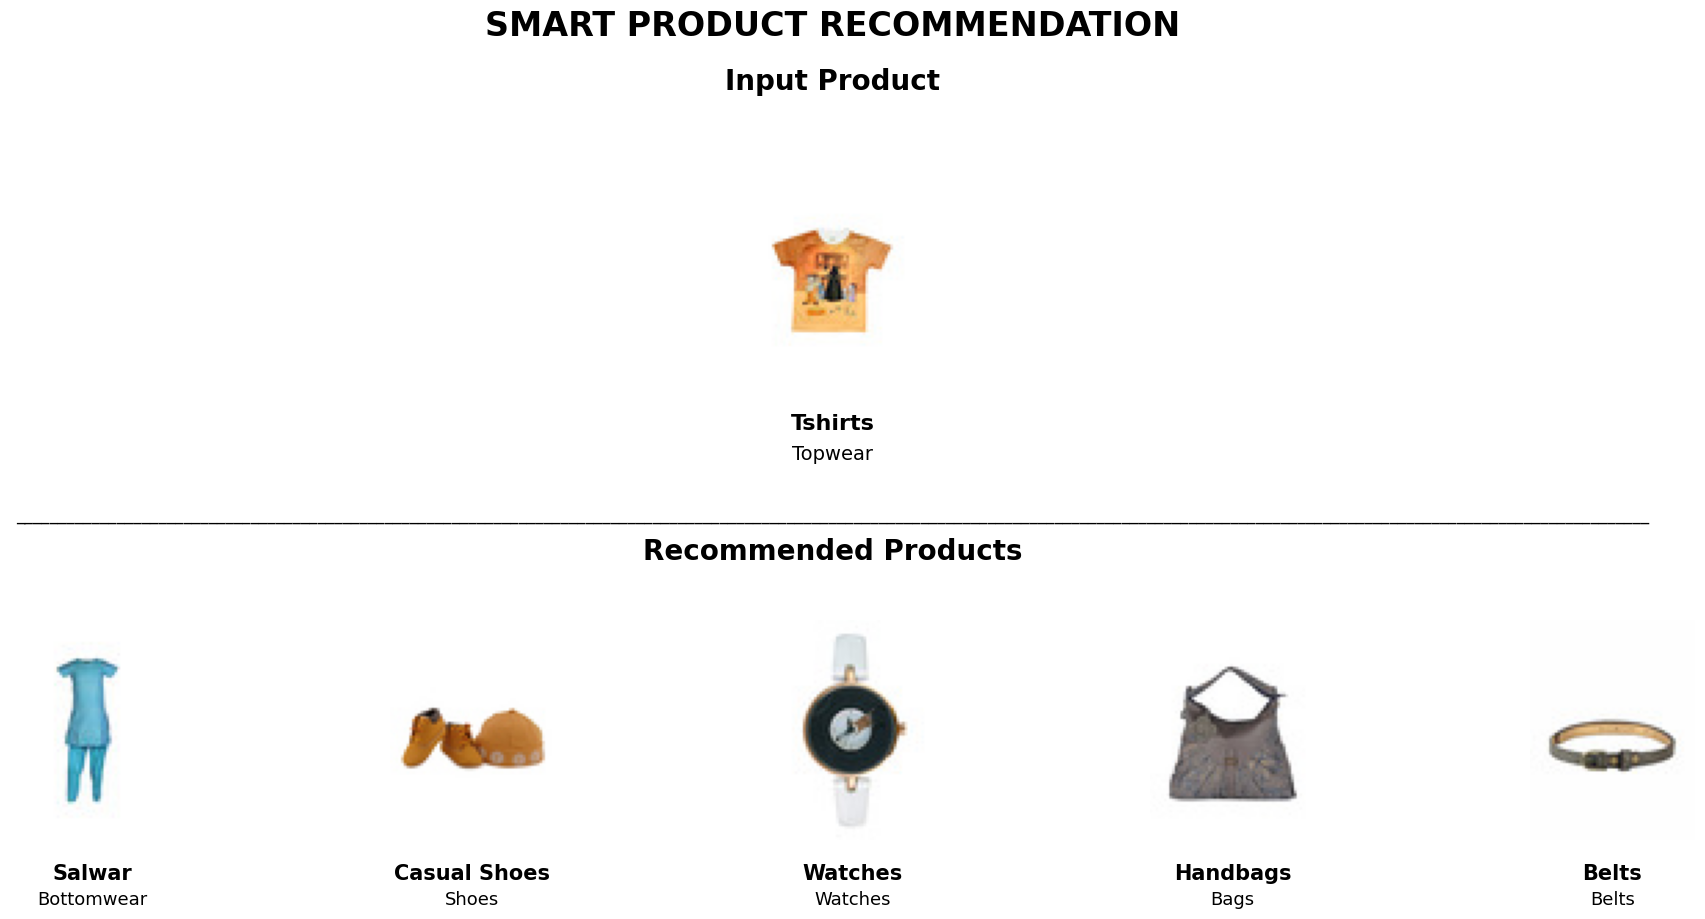

In [18]:
# Step 5: Visualize the Recommendations

from PIL import Image
import matplotlib.pyplot as plt

def show_recommendations(product_id, recommendations):
    """
    Display the input product and its recommended products.
    """

    # Step 5.1: Retrieve the input product
    input_product = df[df["product_id"] == str(product_id)].iloc[0]

    # Step 5.2: Create the figure
    fig = plt.figure(figsize=(20, 10))

    # Main title
    fig.suptitle(
        "SMART PRODUCT RECOMMENDATION",
        fontsize=24,
        fontweight="bold",
        y=0.98
    )

    # Input Product
    fig.text(
        0.5,
        0.90,
        "Input Product",
        ha="center",
        fontsize=20,
        fontweight="bold"
    )

    ax_input = plt.axes([0.43, 0.60, 0.14, 0.22])
    ax_input.imshow(Image.open(input_product["image_path"]))
    ax_input.axis("off")

    fig.text(
        0.5,
        0.56,
        f"{input_product['articleType']}",
        ha="center",
        fontsize=16,
        fontweight="bold"
    )

    fig.text(
        0.5,
        0.53,
        input_product["subCategory"],
        ha="center",
        fontsize=14
    )

    # Divider
    plt.figtext(
        0.5,
        0.47,
        "_" * 195,
        ha="center",
        fontsize=12
    )

    # Recommended Products
    fig.text(
        0.5,
        0.43,
        "Recommended Products",
        ha="center",
        fontsize=20,
        fontweight="bold"
    )

    total = len(recommendations)

    start_x = 0.05
    width = 0.16
    gap = 0.03

    for i, (_, row) in enumerate(recommendations.iterrows()):

        x = start_x + i * (width + gap)

        ax = plt.axes([x, 0.15, width, 0.22])

        ax.imshow(Image.open(row["image_path"]))
        ax.axis("off")

        fig.text(
            x + width / 2,
            0.11,
            row["articleType"],
            ha="center",
            fontsize=15,
            fontweight="bold"
        )

        fig.text(
            x + width / 2,
            0.085,
            row["subCategory"],
            ha="center",
            fontsize=13
        )

    plt.show()

query_product = "17799"

recommendations = recommend_complementary_smart(
    query_product,
    top_k=5
)

show_recommendations(
    query_product,
    recommendations
)

In [19]:
# Step 6: Display Recommendations as Text

def print_recommendations(product_id, recommendations):
    """
    Display the input product and recommended products in text format.
    """

    # Retrieve the input product
    input_product = df[df["product_id"] == str(product_id)].iloc[0]

    print("\nInput Product")
    print("=" * 50)
    print(f"Product ID     : {input_product['product_id']}")
    print(f"Category       : {input_product['subCategory']}")
    print(f"Article Type   : {input_product['articleType']}\n\n")

    print("Recommended Products")
    print("=" * 50)

    for i, (_, row) in enumerate(recommendations.iterrows(), start=1):
        print(f"{i}. {row['articleType']} ({row['subCategory']})")

query_product = "17799"

recommendations = recommend_complementary_smart(
    query_product,
    top_k=5
)

print_recommendations(query_product, recommendations)


Input Product
Product ID     : 17799
Category       : Topwear
Article Type   : Tshirts


Recommended Products
1. Salwar (Bottomwear)
2. Casual Shoes (Shoes)
3. Watches (Watches)
4. Handbags (Bags)
5. Belts (Belts)


In [20]:
# Cosine Similarity Matrix

similarity_matrix = cosine_similarity(image_embeddings)

print("Similarity Matrix Shape:", similarity_matrix.shape)

Similarity Matrix Shape: (2000, 2000)


## Stage 2 – Unique Product Catalog Creation

### Objective

Large e-commerce platforms often contain duplicate or visually similar product listings. The objective of this stage is to identify such products using CLIP image embeddings and generate a unique product catalog by retaining only one representative product from each group.

### Workflow

1. Compute cosine similarity between the image embeddings.
2. Compare each product with the remaining products in the dataset.
3. Identify products with similarity above the predefined threshold as duplicates.
4. Group duplicate products together.
5. Retain one representative product from each group to create the final unique product catalog.

### Duplicate Detection

A cosine similarity threshold is used to identify duplicate products. In this implementation, the threshold is set to **0.95**. If the cosine similarity between two product embeddings is greater than or equal to this threshold, the products are considered visually similar and are grouped into the same duplicate set.

In [21]:
# Detect duplicate products

threshold = 0.95

visited = set()
duplicate_groups = []

for i in range(len(df)):

    if i in visited:
        continue

    group = [i]
    visited.add(i)

    for j in range(i + 1, len(df)):

        if similarity_matrix[i][j] >= threshold:

            group.append(j)
            visited.add(j)

    duplicate_groups.append(group)

print("Total Groups Found:", len(duplicate_groups))

Total Groups Found: 1621


In [22]:
print("First 10 Duplicate Groups\n")

for group in duplicate_groups[:10]:

    ids = df.iloc[group]["product_id"].tolist()

    print(ids)

First 10 Duplicate Groups

['31973']
['30778']
['19812']
['22735']
['38246']
['16916']
['52876', '57971']
['39500']
['44758']
['59454']


### Create the Unique Product Catalog

After identifying duplicate products, one representative product is retained from each duplicate group while the remaining duplicates are excluded. This process results in a streamlined product catalog containing only unique product entries, reducing redundancy and improving catalog quality.

In [23]:
# Build Unique Catalog

unique_indices = [group[0] for group in duplicate_groups]

unique_catalog = df.iloc[unique_indices].reset_index(drop=True)

print("Original Catalog Size :", len(df))
print("Unique Catalog Size   :", len(unique_catalog))

Original Catalog Size : 2000
Unique Catalog Size   : 1621


In [24]:
styles_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv"

styles_df = pd.read_csv(styles_path, on_bad_lines="skip")

print(styles_df.columns)

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')


In [25]:
styles_df["id"] = styles_df["id"].astype(str)
df["product_id"] = df["product_id"].astype(str)

df = df.merge(
    styles_df,
    left_on="product_id",
    right_on="id",
    how="left"
)

In [26]:
print(df.columns.tolist())

unique_catalog = df.iloc[unique_indices].reset_index(drop=True)

['image_path', 'product_id', 'id_x', 'masterCategory_x', 'subCategory_x', 'articleType_x', 'id_y', 'gender', 'masterCategory_y', 'subCategory_y', 'articleType_y', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


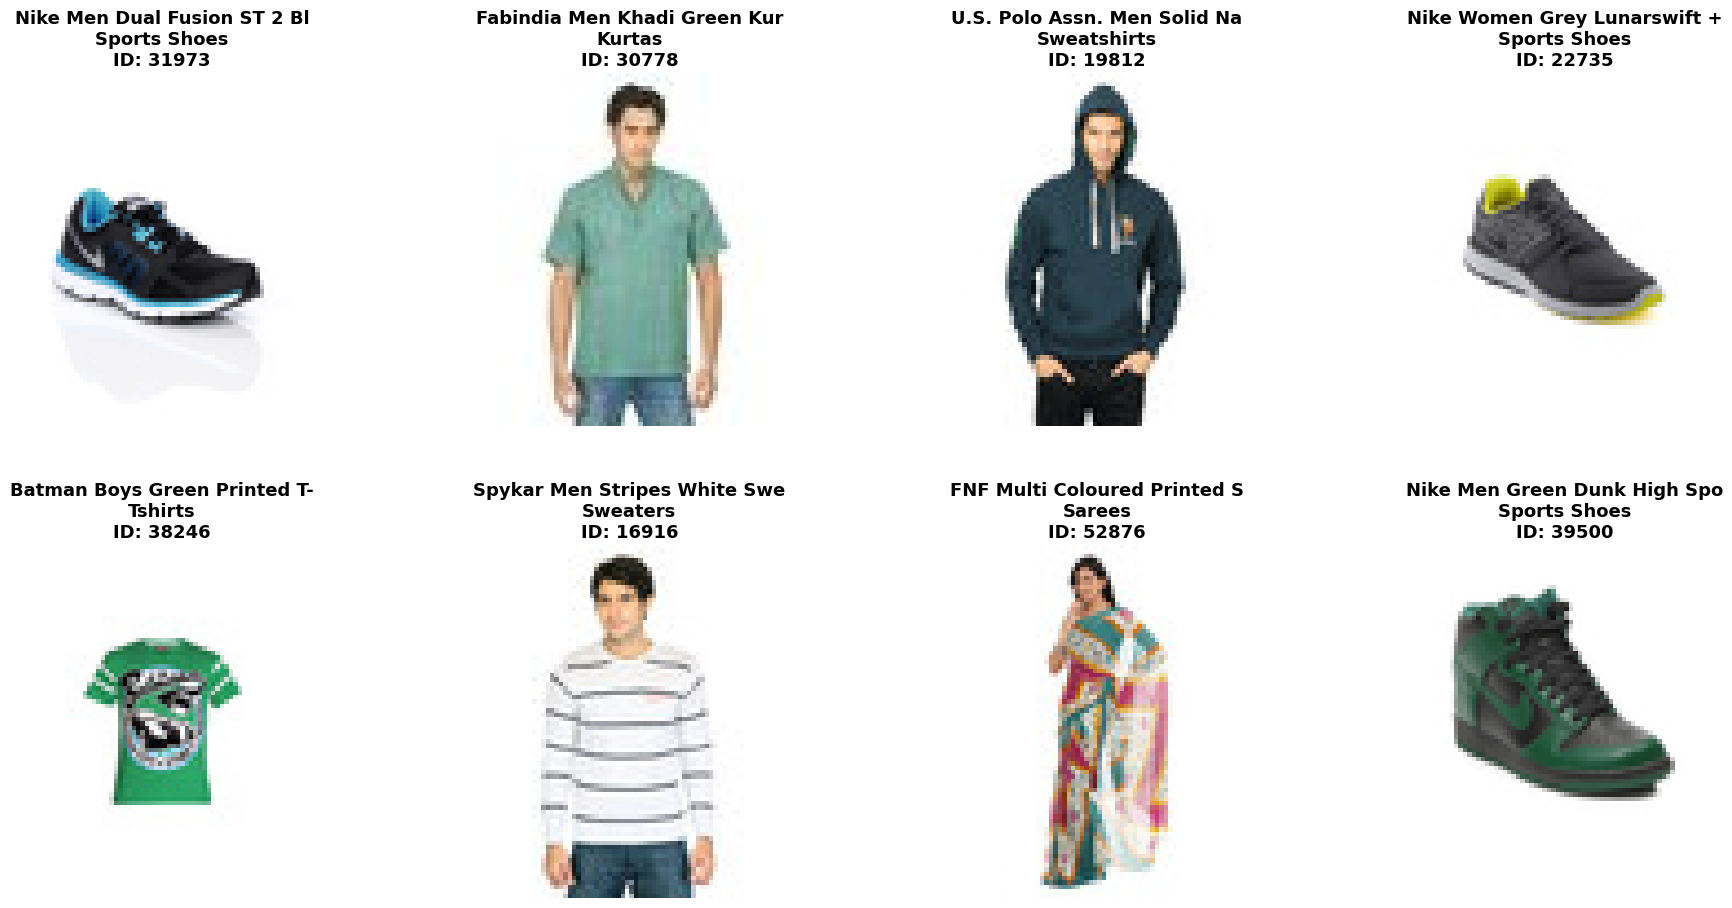

In [27]:
# Display products from the unique catalog

plt.figure(figsize=(20,10))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(Image.open(unique_catalog.iloc[i]["image_path"]))

    plt.title(
        f"{str(unique_catalog.iloc[i]['productDisplayName'])[:28]}\n"
        f"{unique_catalog.iloc[i]['articleType_y']}\n"
        f"ID: {unique_catalog.iloc[i]['product_id']}",
        fontsize=13,
        fontweight="bold"
    )

    plt.axis("off")

plt.tight_layout(pad=4.0)

plt.show()

## Stage 3 – Reverse Product Search (Text-to-Image)

### Objective

This stage implements a reverse product search system that enables users to search for products using natural language descriptions. The input text is converted into a CLIP text embedding and compared with the image embeddings using cosine similarity to identify and retrieve the most relevant product images.

In [28]:
# Function to search products using text

def search_by_text(query, top_k=5):

    # Tokenize input text
    text = clip.tokenize([query]).to(device)

    # Generate text embedding
    with torch.no_grad():
        text_embedding = model.encode_text(text)
        text_embedding /= text_embedding.norm(dim=-1, keepdim=True)

    # Convert to NumPy
    text_embedding = text_embedding.cpu().numpy()

    # Compute cosine similarity
    similarities = cosine_similarity(
        text_embedding,
        image_embeddings
    )[0]

    # Get top matches
    indices = similarities.argsort()[::-1][:top_k]

    return indices

In [29]:
### Test the Reverse Product Search
# The following example searches the product catalog using a natural language query.

query = "red shoes"

results = search_by_text(query)

print("Search Query:", query)

print("\nMatching Products:")

for idx in results:
    print(df.iloc[idx]["product_id"])

Search Query: red shoes

Matching Products:
39742
4482
3670
9088
26452


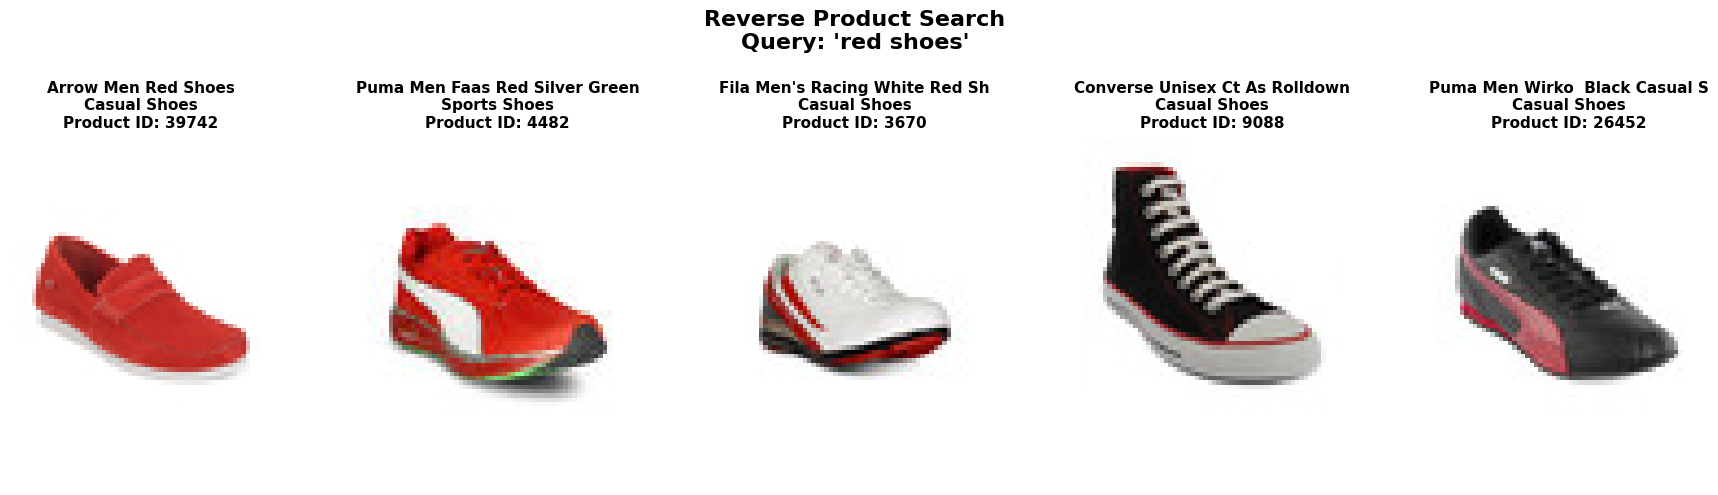

In [30]:
plt.figure(figsize=(18, 5))

for i, idx in enumerate(results):

    plt.subplot(1, 5, i + 1)

    plt.imshow(Image.open(df.iloc[idx]["image_path"]))

    plt.title(
        f"{df.iloc[idx]['productDisplayName'][:30]}\n"
        f"{df.iloc[idx]['articleType_y']}\n"
        f"Product ID: {df.iloc[idx]['product_id']}",
        fontsize=11,
        fontweight="bold"
    )

    plt.axis("off")

plt.suptitle(
    f"Reverse Product Search\nQuery: '{query}'",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.show()

In [31]:
# Display product details in a clean table

results_df = pd.DataFrame({
    "Rank": range(1, len(results)+1),
    "Product ID": [df.iloc[idx]["product_id"] for idx in results],
    "Product Name": [df.iloc[idx]["productDisplayName"] for idx in results],
    "Article Type": [df.iloc[idx]["articleType_y"] for idx in results]
})

results_df.index = [""] * len(results)   # Hide default DataFrame index

display(results_df)

,Rank,Product ID,Product Name,Article Type
,1,39742,Arrow Men Red Shoes,Casual Shoes
,2,4482,Puma Men Faas Red Silver Green Shoe,Sports Shoes
,3,3670,Fila Men's Racing White Red Shoe,Casual Shoes
,4,9088,Converse Unisex Ct As Rolldown Hi Black Casual...,Casual Shoes
,5,26452,Puma Men Wirko Black Casual Shoes,Casual Shoes


## Stage 4 – Conclusion

### Summary

This project demonstrated the use of OpenAI's CLIP model to develop an AI-powered product intelligence system for an e-commerce platform. By leveraging multimodal embeddings, the system successfully performed visual similarity analysis and semantic search across product images.

The following functionalities were implemented:

- Smart Product Recommendation Engine
- Unique Product Catalog Creation
- Reverse Product Search (Text-to-Image)

The shared embedding space provided by CLIP enabled both image-to-image and text-to-image retrieval, making it possible to support multiple product intelligence tasks using a single feature representation.

Overall, the developed system illustrates how multimodal AI can enhance product discovery, reduce duplicate listings, and improve the efficiency of product catalog management in modern e-commerce applications.

## Stage 5 – Challenges and Future Improvements

### Challenges

During the implementation of this project, several challenges were encountered:

- Selecting an appropriate cosine similarity threshold for reliable duplicate product detection.
- Efficiently processing a large collection of product images while maintaining reasonable execution time.
- Integrating image data with product metadata to ensure consistency across different stages of the workflow.

### Future Improvements

The current implementation can be extended in several ways to enhance its capabilities:

- Fine-tune the CLIP model on fashion-specific datasets to improve retrieval accuracy.
- Develop an interactive web application using frameworks such as Streamlit or Gradio.
- Support both image-to-image and text-to-image search within a unified interface.
- Incorporate user preferences and browsing history to provide personalized product recommendations.

## Final Results

The developed AI-powered product intelligence system successfully demonstrates the application of multimodal AI techniques in an e-commerce environment. By leveraging OpenAI's CLIP model, the system effectively performs image-based recommendations, duplicate product detection, and text-based product retrieval using a shared embedding representation.

### Features Implemented

- Smart Product Recommendation Engine
- Unique Product Catalog Creation
- Reverse Product Search (Text-to-Image)

The generated CLIP embeddings were reused across all implemented tasks, improving computational efficiency and demonstrating the flexibility of a unified multimodal representation for product intelligence applications.